In [1]:
from pathlib import Path


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in (start, *start.parents):
        if (path / "data" / "loader_roots").exists():
            return path
    raise FileNotFoundError("Could not find data/loader_roots from the current working directory.")


PROJECT_ROOT = find_project_root()
XJTU_ROOT = str(PROJECT_ROOT / "data" / "loader_roots" / "xjtu")
PHM2012_ROOT = str(PROJECT_ROOT / "data" / "loader_roots" / "phm2012")

import torch
from torch.nn import MSELoss

from phm.data import Dataset
from phm.data.loader.XJTULoader import XJTULoader
from phm.data.labeler.BearingRulLabeler import BearingRulLabeler
from phm.data.process.EntityPipeline import EntityPipeline
from phm.data.process.array.RMSProcessor import RMSProcessor
from phm.engine.metric.PHM2012Score import PHM2012Score
from phm.engine.metric.PercentError import PercentError
from phm.engine.metric.MAE import MAE
from phm.engine.metric.MSE import MSE
from phm.engine.metric.RMSE import RMSE
from phm.data.process.entity.ThreeSigmaFPTCalculator import ThreeSigmaFPTCalculator
from phm.engine.tester.BaseTester import BaseTester
from phm.engine.trainer.BaseTrainer import BaseTrainer
from phm.model.basic.CNN import CNN
from phm.engine.Evaluator import Evaluator
from phm.engine.callback.CheckGradientsCallback import CheckGradientsCallback
from phm.engine.callback.EarlyStoppingCallback import EarlyStoppingCallback
from phm.engine.callback.TensorBoardCallback import TensorBoardCallback
from phm.util.Cache import Cache
from phm.util.Plotter import Plotter
from phm.util.Device import select_torch_device


In [2]:
cache_dataset = True
# cache_dataset = False
# cache_model = True
cache_model = False

Plotter.DPI = 50
Plotter.SIZE = (10, 6)

# 获取数据集

In [3]:
dataset = Cache.load('prognosis_bearing_dataset', is_able=cache_dataset)
if dataset is None:
    data_loader = XJTULoader(XJTU_ROOT)
    labeler = BearingRulLabeler(2048, is_from_fpt=False, is_rectified=True)

    pipeline = EntityPipeline()
    pipeline.register(
        processor=RMSProcessor(data_loader['continuum']),
        input_key='Horizontal Vibration',
        output_key='H_RMS'
    )
    pipeline.register(
        processor=ThreeSigmaFPTCalculator(),
        input_key='H_RMS',
    )

    dataset = Dataset()
    for bearing_name in ['Bearing1_1', 'Bearing1_2', 'Bearing1_3',
                         'Bearing2_1', 'Bearing2_2',
                         'Bearing3_1', 'Bearing3_2']:
        bearing = data_loader(bearing_name, 'Horizontal Vibration')
        pipeline.execute(bearing)
        dataset.append_entity(labeler(bearing, key='Horizontal Vibration'))
    Cache.save(dataset, 'prognosis_bearing_dataset')

[DEBUG   22:06:09]  [Cache]  -> Loading cache file: cache/prognosis_bearing_dataset.pkl
[DEBUG   22:06:09]  [Cache]  Successfully loaded: cache/prognosis_bearing_dataset.pkl


# 划分测试集、训练集、验证集

In [4]:
test_set = dataset.include(['Bearing1_1', 'Bearing1_3'])
train_set = dataset.exclude(['Bearing1_1', 'Bearing1_3'])
val_set, train_set = train_set.split_by_ratio(0.3)

[INFO    22:06:14]  [Dataset]  Splitting data by ratio 0.3 using random seed: 21930081023258930493363163320387710329


# 配置测试算法

In [5]:
test_config = {
    'device': select_torch_device(),
    'dtype': torch.float32,
}
tester = BaseTester(config=test_config)

# 配置训练算法

In [6]:
train_config = {
    'device': select_torch_device(),
    'dtype': torch.float32,
    'epochs': 20,
    'batch_size': 256,
    'lr': 0.01,
    'weight_decay': 0.0,
    'criterion': MSELoss(),
    'callbacks': [
        EarlyStoppingCallback(patience=5,
                              val_set=val_set,
                              metric=RMSE(),
                              tester=tester),
        TensorBoardCallback(),
        CheckGradientsCallback()
    ]
}
trainer = BaseTrainer(config=train_config)

# 定义模型并训练

[INFO    22:06:17]  
[Trainer]  Start training by BaseTrainer:
	training set: Bearing1_2; Bearing2_1; Bearing2_2;…
	device: mps
	dtype: torch.float32
	epochs: 20
	batch_size: 256
	lr: 0.01
	weight_decay: 0.0
	criterion: MSELoss()
	callbacks: [EarlyStoppingCallback, TensorBoardCallback, CheckGradientsCallback]
	optimizer: Adam
[DEBUG   22:06:19]  [EarlyStopping]  On the validation set Bearing1_2; Bearing2_1; Bearing2_2; Bearing3_1; Bearing3_2, the RMSE is 0.9445
[INFO    22:06:25]  [BaseTrainer]  Epoch [1/20], MSELoss:0.0388
[DEBUG   22:06:26]  [EarlyStopping]  On the validation set Bearing1_2; Bearing2_1; Bearing2_2; Bearing3_1; Bearing3_2, the RMSE is 0.0856
[WARNING 22:06:29]  [CheckGradients] se1.excitation.0.weight gradient is very small: 0.00e+00
[WARNING 22:06:29]  [CheckGradients] se1.excitation.0.bias gradient is very small: 0.00e+00
[WARNING 22:06:29]  [CheckGradients] se1.excitation.2.weight gradient is very small: 0.00e+00
[WARNING 22:06:29]  [CheckGradients] se2.excitation.

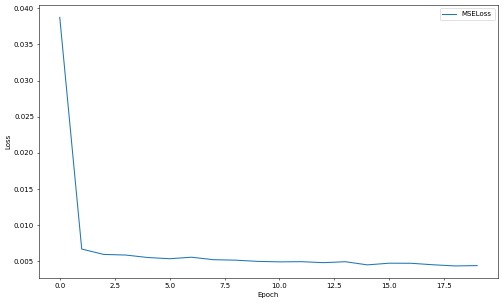

[DEBUG   22:07:52]  [Cache]  Generating cache file: cache/prognosis_bearing_model.pkl
[DEBUG   22:07:52]  [Cache]  Generated cache file: cache/prognosis_bearing_model.pkl


In [7]:
model = Cache.load('prognosis_bearing_model', cache_model)
if model is None:
    model = CNN(2048, 1, end_with_sigmoid=False)
    # 开始训练
    losses = trainer.train(model=model, train_set=train_set)
    Plotter.loss(losses)
    Cache.save(model, 'prognosis_bearing_model')

# 测试模型

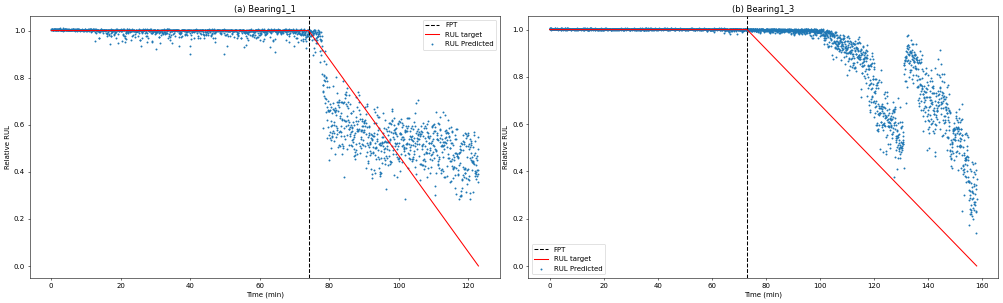

'default'

In [8]:
result = tester.test(model, test_set)
Plotter.rul_end2end(test_set, result, is_scatter=True, label_x='Time (min)', label_y='Relative RUL')

# 预测结果评价

In [9]:
evaluator = Evaluator()
evaluator.add(MAE(), MSE(), RMSE(), PercentError(), PHM2012Score())
evaluator(test_set, result)

/Users/nev8r/Desktop/phm2/.venv/lib/python3.11/site-packages/phm/engine/metric/PHM2012Score.py:33: RuntimeWarning: overflow encountered in exp
  np.exp(np.log(0.5) * (percent_error / 20)))
[INFO    22:07:53]  
[Evaluator]  Performance Evaluation:
                 MAE     MSE    RMSE PercentError PHM2012Score
Bearing1_1    0.0777  0.0203  0.1424       -3.27%       0.6982
Bearing1_3    0.1689  0.0661  0.2571      -23.08%       0.4841
mean(global)  0.1290  0.0461  0.2146      -13.96%       0.5779
mean(group)   0.1290  0.0461  0.2069      -14.41%       0.5778



,MAE,MSE,RMSE,PercentError,PHM2012Score
Bearing1_1,0.0777,0.0203,0.1424,-3.27%,0.6982
Bearing1_3,0.1689,0.0661,0.2571,-23.08%,0.4841
mean(global),0.1290,0.0461,0.2146,-13.96%,0.5779
mean(group),0.1290,0.0461,0.2069,-14.41%,0.5778
